In [33]:
import os
import sys
notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)
import logging
import json
from matplotlib import gridspec
from typing import List
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl
import dataframe_image as dfi
from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
import force_regression.utils.io as io
import force_regression.evaluation.compile_results as cr
from force_regression.models.snn import *
from hydra import initialize_config_dir, compose
import force_regression.utils.configuration as lrc

from configs.constants import *

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')

logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/analysis
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [80]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        subject_mappings = config['subject_mappings']
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

results_dir = 'output_files'
source_data_main_file = 'SourceDataMain.xlsx'
source_data_si_file = 'SourceDataSupplementary.xlsx'


Root directory from config: /Volumes/big usb drive/HDiEMG_mu_decomposition


# Data configuration

In [18]:
SELECT_TORCH_SEED = 90

In [19]:
# used to retrieve the figs_dir
data_config = DataConfig(root_dir=root_dir,
                         root_results_dir = root_results_dir,
                          subject=fn.reverse_remap("S1", subject_mappings),
                          task_type="Trap",
                          finger_type="Individual",
                          day="Day 1",
                          emg_type="intra",
                          f_samp=10240,
                          subj_map=subject_mappings,
                          segment_hold=True, 
                          verbose=False,
                          common_only=True,
                          images=False,
                          time_to_cut=1,
                          results_dir=results_dir)
output_figures_dir = os.path.join(data_config.root_results_dir, data_config.figs_dir)
snn_spiking_dir ='SNN/shallow_spiking_double_filter/post_process_filt'
snn_leaky_dir = 'SNN/shallow_leaky/post_process_filt'

In [20]:
data_config.decomp_dir

'/Volumes/big usb drive/HDiEMG_mu_decomposition/AK/Day 1/decomposition/Trap/15'

In [21]:
save_figure = False
type_pred_metric = 'post'
subjects = ["S1","S2"]

model_short_to_full = {'intra mu spike count': 'motor units spike count',
                       'intra mu spike times': 'motor units spike times'}

models_palette_dict = {'intra mu spike count': '#FF6F5C',
                       f'intra mu spike times {SHALLOW_LEAKY}': sns.color_palette(palette='Accent')[0],
                       f'intra mu spike times {SHALLOW_SPIKING_DOUBLE_FILTER}': COLORS['belize'],
                       }
topology_legend_name_map = {SHALLOW_LEAKY:'LI', SHALLOW_SPIKING_DOUBLE_FILTER:'LIF'}

# Load models results

Here, we extract the metrics and the force predictions

In [56]:
subjects = ["S1", "S2"] 

metrics_compiled_df_snn_spiking = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='metrics_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_SPIKING_DOUBLE_FILTER}',
                                                                    results_dir=results_dir,
                                                                    config=config)

y_compiled_df_snn_spiking = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='y_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_SPIKING_DOUBLE_FILTER}',
                                                                    results_dir=results_dir,
                                                                    config=config)


metrics_compiled_df_snn_leaky = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='metrics_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_LEAKY}',
                                                                    results_dir=results_dir,
                                                                    config=config)

y_compiled_df_snn_leaky = cr.load_and_parse_snn_data_to_df(dt=0.01, subject_list=subjects,
                                                                    data_type='y_df_cv_snn',
                                                                    network_topology=f'{SHALLOW_LEAKY}',
                                                                    results_dir=results_dir,
                                                                    config=config)


print(f"\nMetrics shape:{metrics_compiled_df_snn_spiking.shape}\nMVCs:{metrics_compiled_df_snn_spiking[MVC_COL].unique()}\nSign MVCS:{metrics_compiled_df_snn_spiking[SIGN_MVC_COL].unique()}")

# Extract the corresponding conventional model results as always
metrics_compiled_df_conv_separate = cr.load_and_parse_df_data(subject_list=subjects, data_type='metrics_df',
                                                              config=config,
                                                              results_dir=results_dir)
y_compiled_df_conv_separate = cr.load_and_parse_df_data(subject_list=subjects, data_type='y_df',
                                                        config=config, results_dir=results_dir,
                                                        is_multi=False)

metrics_compiled_df_conv_separate = metrics_compiled_df_conv_separate[metrics_compiled_df_conv_separate[SUBJECT_COL].isin(subjects)]
y_compiled_df_conv_separate = y_compiled_df_conv_separate[y_compiled_df_conv_separate[SUBJECT_COL].isin(subjects)]
print(f"------------\nMetrics shape:{metrics_compiled_df_conv_separate.shape}\nMVCs:{metrics_compiled_df_conv_separate[MVC_COL].unique()}\nSign MVCS:{metrics_compiled_df_conv_separate[SIGN_MVC_COL].unique()}")

Loading data for subject S1 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/shallow_spiking_double_filter
Loading file: metrics_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_9_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_15_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_29_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_89_

Loading data for subject S2 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S2/SNN/shallow_spiking_double_filter
Loading file: y_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_29_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_29_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_89_noise_None_ns_100_taufilt1_0.05_tau

Loading file: y_df_cv_snn_ep_100_seed_9_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_28_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_15_noise_None_ns_100_taufilt1_0.05_taufilt2_0.08_tausyn_0.01_minit_0.03_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading data for subject S1 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S1/SNN/shallow_leaky
Loading file: metrics_df_cv_snn_ep_100_seed_89_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: metrics_df_cv_snn_ep_100_seed_9_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08

Loading file: y_df_cv_snn_ep_100_seed_0_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_0_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_15_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_90_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_29_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading data for subject S2 from /Volumes/big usb drive/snn-fingerforce-decoding-results/results/output_files/S2/SNN/shallow_leaky
Loading file: y_df_cv_snn_ep_100_se

Loading file: y_df_cv_snn_ep_100_seed_90_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_8_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_89_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_73_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_29_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_-1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv_snn_ep_100_seed_64_noise_None_ns_100_taufilt1_0.08_tausyn_0.01_taumem_0.08_dt_0.01_sign_1_mvc_15_kfold_2_hold_False.pkl
Loading file: y_df_cv

INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [-1  1]

INFO:root:Loaded data for 2 subjects: ['S1' 'S2']
MVC:[15]
Window size: [0.08]
Overlap: [50]
Sign MVC: [ 1 -1]



metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
metrics_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
y_df_intra_ws0.08_ol50_1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
y_df_intra_ws0.08_ol50_-1_15_cv_on_mu_nfing_1_2_3_4_5_shuffleseed_10_linear_hold_False.pkl
------------
Metrics shape:(40, 26)
MVCs:[15]
Sign MVCS:[-1  1]


# Load SNN configurations

In [57]:

abs_config_dir=os.path.abspath("../../configs/hydra")
with initialize_config_dir(version_base=None, config_dir=abs_config_dir):
    cfg_leaky = compose(config_name="snn",
                  overrides=["decoder_type=leaky",
                            "logging.wandb.use_wandb=False",
                             ])
    cfg_spiking = compose(config_name="snn",
                  overrides=["decoder_type=spiking",
                            "logging.wandb.use_wandb=False",
                             ])
flat_leaky_config = lrc.flatten_hydra_config(cfg_leaky)
flat_spiking_config = lrc.flatten_hydra_config(cfg_spiking)


In [58]:
# 1. Compute the mean and std across folds for these MVC for the SNN and conv models
mean_std_df_snn = pd.DataFrame()
snn_samples = pd.DataFrame()

mean_std_df_conv = pd.DataFrame()
conv_samples = pd.DataFrame()

convreg_metric = 'post'
pvalue_on_metric = 'RMSE'

temp_snn_spiking_df, temp_snn_spiking_samples = cr.compute_mean_sd_snn_metric(metrics_compiled_df_snn_spiking,
                                                                mvc=15,
                                                                return_samples=True)
temp_snn_leaky_df, temp_snn_leaky_samples = cr.compute_mean_sd_snn_metric(metrics_compiled_df_snn_leaky,
                                                                mvc=15,
                                                                return_samples=True)

# add topology column to the dataframes
temp_snn_spiking_df[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER
temp_snn_leaky_df[TOPOLOGY_COL] = SHALLOW_LEAKY
temp_snn_spiking_samples[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER
temp_snn_leaky_samples[TOPOLOGY_COL] = SHALLOW_LEAKY

temp_conv_df, temp_conv_samples = cr.compute_mean_sd_metric(compiled_df=metrics_compiled_df_conv_separate,
                                                            mvc=15,
                                                            return_samples=True,
                                                            type_pred_metric=convreg_metric,
                                                            get_samples_for_metric=pvalue_on_metric)


mean_std_df_snn = pd.concat([mean_std_df_snn, temp_snn_spiking_df, temp_snn_leaky_df], axis=0, ignore_index=True)
snn_samples = pd.concat([snn_samples, temp_snn_spiking_samples, temp_snn_leaky_samples], axis=0, ignore_index=True)

mean_std_df_conv = pd.concat([mean_std_df_conv, temp_conv_df], axis=0, ignore_index=True)
conv_samples = pd.concat([conv_samples, temp_conv_samples], axis=0, ignore_index=True)

# map finger name to integer for plotting
mean_std_df_conv[FING_ID_COL] = mean_std_df_conv[FING_NAME_COL].map({fing: idx for idx, fing in enumerate(fing_order)})
conv_samples[MODEL_SHORT_NAME_COL] = conv_samples.apply(lambda x:f"{x[EMG_COL]} {x[INPUT_TYPE_COL].lower()}", axis=1)
conv_samples = conv_samples[conv_samples[MODEL_SHORT_NAME_COL].isin(['intra mu spike count'])]


snn_aux_col = [TAU_SYN_COL, TAU_MEM_COL, TAU_SYN_INIT_COL, TAU_MEM_INIT_COL,
               TAU1_MEM_FILT_COL, TAU2_MEM_FILT_COL,EPOCHS_COL] +\
               ['MAE_test','MSE_test', TEST_ON_REP, 'input_dur', REG_FING_COL, 'mode']
if pvalue_on_metric == 'RMSE':
    snn_aux_col += ['R2_test']
elif pvalue_on_metric == 'R2':
    snn_aux_col += ['RMSE_test']

snn_samples[MODEL_SHORT_NAME_COL] = snn_samples.apply(lambda x:f"{x[EMG_COL]} {x[INPUT_TYPE_COL].lower()}", axis=1)

# update to match the format of the metric_samples_per_mvc
snn_samples = snn_samples.rename(columns={f'{pvalue_on_metric}_test': f'{pvalue_on_metric}_test_{type_pred_metric}'})
snn_samples = snn_samples[snn_samples[EPOCHS_COL]==100]

Computing mean across 10 torch seeds:[ 8  9 73 15 29 89 28  0 90 64]
Computing mean across 10 torch seeds:[89  9 28 64 15  0  8 29 90 73]


In [109]:
metrics_compiled_df_conv_separate.groupby([SEGMENT_HOLD_COL,SUBJECT_COL, MVC_COL])['RMSE_test_post'].mean()

segment_hold  subject  mvc
False         S1       15     1.731957
              S2       15     2.132403
Name: RMSE_test_post, dtype: float32

In [59]:
metrics_compiled_df_conv_separate.groupby([SEGMENT_HOLD_COL,SUBJECT_COL, MVC_COL, SIGN_MVC_COL])['RMSE_test_post'].mean()

segment_hold  subject  mvc  sign_mvc
False         S1       15   -1          2.155425
                             1          1.308488
              S2       15   -1          2.058558
                             1          2.206248
Name: RMSE_test_post, dtype: float32

In [60]:
metrics_compiled_df_conv_separate.groupby([SEGMENT_HOLD_COL,SUBJECT_COL, MVC_COL, SIGN_MVC_COL])['RMSE_test_post'].std()

segment_hold  subject  mvc  sign_mvc
False         S1       15   -1          0.668075
                             1          0.223345
              S2       15   -1          0.411870
                             1          0.865097
Name: RMSE_test_post, dtype: float32

# Effect Size and 95% CI

In [61]:
def mask_torch_seed(df, torch_seed):
    """
    Masks the dataframe based on the given torch seed.
    """
    if torch_seed is None:
        df_seed = df[df[TORCH_SEED_COL].isnull()]
    else:
        df_seed = df[df[TORCH_SEED_COL] == torch_seed]
    return df_seed

In [62]:
# Measure effect size
snn_topologies = snn_samples[TOPOLOGY_COL].unique()
snn_topologies = sorted(snn_topologies, key=lambda x: x.split())  
effect_sizes_df = pd.DataFrame()
for topology in snn_topologies:
    topology_samples_df = snn_samples[snn_samples[TOPOLOGY_COL]==topology]
    all_samples_df = pd.concat([conv_samples, topology_samples_df], axis=0, ignore_index=True)
    temp_df = cr.compute_pairwise_effect_sizes(all_samples_df, 
                                                model_short_to_full, 
                                                remove_mvcs=[],
                                                metric=f'{pvalue_on_metric}_test_post',
                                                normalized_metric=False,
                                                seed_col=TORCH_SEED_COL)
    temp_df['topology_snn'] = topology                                            
    effect_sizes_df = pd.concat([effect_sizes_df, temp_df], axis=0, ignore_index=True)


Averaging across 10 seeds ([nan 89.  9. 28. 64. 15.  0.  8. 29. 90. 73.]) per fold/finger/direction
Check on bootstrap mean:0.0036551577860117306 +/- 0.02279939313155023
Check on bootstrap mean:-0.17985982900023462 +/- 0.1319728796089316
Averaging across 10 seeds ([nan  8.  9. 73. 15. 29. 89. 28.  0. 90. 64.]) per fold/finger/direction
Check on bootstrap mean:-0.04652493626832961 +/- 0.05359686643261886
Check on bootstrap mean:0.009380655844211553 +/- 0.05692444189665174


In [ ]:
# save effect sizes df to csv
output_path = os.path.join(data_config.root_results_dir,'stats', 'effect_sizes_LR_SNN_leaky_spiking_95CI.csv')
effect_sizes_df.to_csv(output_path, index=False)

In [63]:
effect_sizes_df.groupby(['subject','model1', 'model2', 'topology_snn', 'mean_diff','mean_diff_ci_lower', 'mean_diff_ci_upper'])['mean_diff_ci_upper'].value_counts()

subject  model1                model2                topology_snn                   mean_diff  mean_diff_ci_lower  mean_diff_ci_upper
S1       intra mu spike count  intra mu spike times  shallow_leaky                   0.003719  -0.245332           0.252771              1
                                                     shallow_spiking_double_filter  -0.046374  -0.305725           0.212976              1
S2       intra mu spike count  intra mu spike times  shallow_leaky                  -0.179489  -0.635433           0.276455              1
                                                     shallow_spiking_double_filter   0.009541  -0.440690           0.459771              1
Name: count, dtype: int64

# Plot models comparison

In [65]:
snn_samples.groupby(['subject',TOPOLOGY_COL, EPOCHS_COL])['RMSE_test_post'].count()

subject  topology                       n_epochs
S1       shallow_leaky                  100         200
         shallow_spiking_double_filter  100         200
S2       shallow_leaky                  100         200
         shallow_spiking_double_filter  100         200
Name: RMSE_test_post, dtype: int64

In [66]:
def plot_snn_comparison_boxplot(snn_samples, conv_samples,
                                subjects:List[str], 
                                models_palette_dict:dict, 
                                save_figure:bool=False,
                                yticks:np.ndarray=np.arange(0,25,5), 
                                metric:str=f'{RMSE_TRAIN}_filtered',
                                normalized_metric:bool=False,
                                source_data_path:str=None,
                                sheet_name:str= "boxplot_snn_lr"):

    # figure styling
    box_plot_alpha = 0.7
    snn_topologies = snn_samples[TOPOLOGY_COL].unique()
    snn_topologies = sorted(snn_topologies, key=lambda x: x.split())
    print(snn_topologies)
    print(f"topologies:{snn_topologies}")
    metric_name = f'{metric}_norm' if normalized_metric else metric
    mvcs = snn_samples[MVC_COL].unique()
    assert len(mvcs) == conv_samples[MVC_COL].nunique(), "MVCs are not the same in the two dataframes"

    fig = plt.figure(figsize=(3, 5))
    gs = gridspec.GridSpec(nrows=2, ncols=1)
    boxplot_width = 0.5
    shift_scatter = 0.3
    snn_box_edge_color = COLORS['midnight_blue']
    snn_mean, snn_std = {}, {}
    for i, sub in enumerate(subjects): 
        ax = fig.add_subplot(gs[i])
        # first plot conv samples
        masked_conv_samples = conv_samples[(conv_samples[SUBJECT_COL] == sub)]

        ax.boxplot([masked_conv_samples[metric_name]], positions=[0], widths=boxplot_width,
                    patch_artist=True,
                    boxprops=dict(facecolor=models_palette_dict[f'intra {INPUT_TYPE_SP_COUNT.lower()}'],
                                  alpha=box_plot_alpha),
                    flierprops=dict(marker='o',
                                    markersize=4,
                                    alpha=1,
                                    color=COLORS['midnight_blue'],
                                    markeredgewidth=0.5),
                    medianprops=dict(color=COLORS['midnight_blue'])
                    )
        ax.scatter(np.repeat(0, masked_conv_samples.shape[0]) - shift_scatter, 
                    masked_conv_samples[metric_name], 
                    c=models_palette_dict[f'intra {INPUT_TYPE_SP_COUNT.lower()}'], s=7, alpha=0.7)

        # then plot snn samples
        for j, topology in enumerate(snn_topologies):
            topology_color = models_palette_dict[f'intra {INPUT_TYPE_SP_TIMES.lower()} {topology}']
            topology_samples_df = snn_samples[snn_samples[TOPOLOGY_COL]==topology]
            topology_samples_df = topology_samples_df[topology_samples_df[SUBJECT_COL] == sub]
            snn_mean[topology] = topology_samples_df[metric_name].mean()
            snn_std[topology] = topology_samples_df[metric_name].std()
            ax.boxplot([topology_samples_df[metric_name]], positions=[j+1], widths=boxplot_width,
                       patch_artist=True, boxprops=dict(facecolor=topology_color,
                                                        alpha=box_plot_alpha,
                                                        edgecolor=snn_box_edge_color),
                       flierprops=dict(marker='o', markersize=4, alpha=1,
                                       color=COLORS['midnight_blue'], markeredgewidth=0.5),
                       medianprops=dict(color=COLORS['midnight_blue']))
            print("N scatter points for topology {}: {}".format(topology, topology_samples_df.shape[0]))
            ax.scatter(np.repeat(j+1,topology_samples_df.shape[0]) - shift_scatter, 
                        topology_samples_df[metric_name], 
                        c=topology_color,
                        edgecolors=snn_box_edge_color, 
                        s=7, alpha=0.7)            
            
        # Define labels for x ticks
        xtick_labels = ['OLS LR'] + [f'SNN {topology_legend_name_map[topology]}' for topology in snn_topologies]
        ax.set_xticks(range(len(xtick_labels)))
        ax.set_xticklabels(xtick_labels, rotation=20, ha='right')
        plt.yticks(yticks)
        ax.set_ylabel('')
        ax.set_title(f"Subject {sub.split('S')[-1]}")
        if 'RMSE' in metric:
            ax.set_ylabel(RMSE_LABEL, labelpad=YLAB_PAD) if not normalized_metric else ax.set_ylabel(NORM_RMSE_LABEL, labelpad=YLAB_PAD)
        if 'R2' in metric:
            ax.set_ylabel(R2_LABEL, labelpad=YLAB_PAD)
        ax.yaxis.set_label_coords(-0.1, 0.35)
        sns.despine(ax=ax, offset=0, trim=True)

    fig.tight_layout()

    if save_figure:
        mvcs_string = '_'.join([str(m) for m in mvcs])
        # Saving to pdf
        fig.savefig(os.path.join(output_figures_dir, f'SNN_LR_boxplot_topologies_for_mvc_{mvcs_string}_{metric}_post_filt_seed_{SELECT_TORCH_SEED}_nolegend_nostat.pdf'),
                    dpi=300, bbox_inches='tight')
        
        if source_data_path is not None:
            rows = []
            for sub in subjects:
                # Baseline (conv) scatter points
                masked_conv = conv_samples[conv_samples[SUBJECT_COL] == sub]
                for val in masked_conv[metric_name]:
                    rows.append({SUBJECT_COL: sub, TOPOLOGY_COL: 'OLS LR', MVC_COL: masked_conv[MVC_COL].iloc[0], metric_name: val})
                # SNN scatter points per topology
                for topology in snn_topologies:
                    tdf = snn_samples[(snn_samples[TOPOLOGY_COL] == topology) & (snn_samples[SUBJECT_COL] == sub)]
                    for val in tdf[metric_name]:
                        rows.append({SUBJECT_COL: sub, TOPOLOGY_COL: topology, MVC_COL: tdf[MVC_COL].iloc[0], metric_name: val})
            io.save_to_source_data(source_data_path, pd.DataFrame(rows), sheet_name=sheet_name)

['shallow_leaky', 'shallow_spiking_double_filter']
topologies:['shallow_leaky', 'shallow_spiking_double_filter']
N scatter points for topology shallow_leaky: 20
N scatter points for topology shallow_spiking_double_filter: 20
N scatter points for topology shallow_leaky: 20
N scatter points for topology shallow_spiking_double_filter: 20
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig2b_snn_lr'.


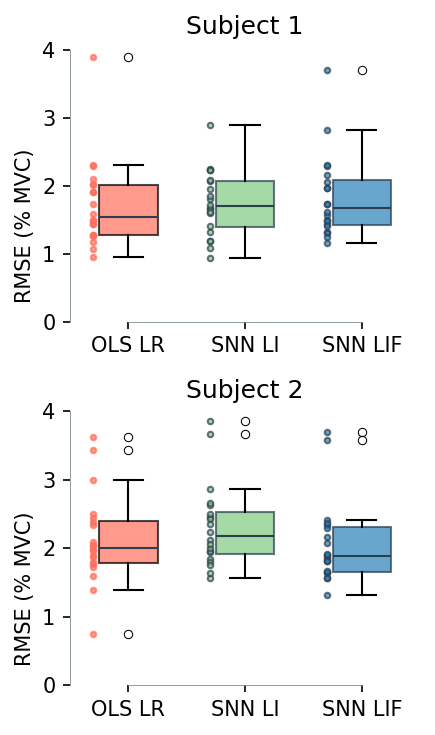

In [67]:
snn_samples_seed = mask_torch_seed(snn_samples, SELECT_TORCH_SEED)

if pvalue_on_metric == RMSE:
    plot_snn_comparison_boxplot(snn_samples_seed, 
                                conv_samples,
                                subjects,
                                models_palette_dict,
                                yticks=np.arange(0, 5, 1),
                                metric=f'{RMSE}_test_post',
                                save_figure=True,
                                source_data_path=os.path.join(project_dir, source_data_main_file),
                                sheet_name="Fig2b_snn_lr")

# Display mean/std of the baseline model

In [11]:
# These are already the means across folds
mean_std_df_conv.groupby([SUBJECT_COL, SIGN_MVC_COL, MVC_COL, INPUT_TYPE_COL, SEGMENT_HOLD_COL])['R2_test_mean'].count()

subject  sign_mvc  mvc  input_type      segment_hold
S1       -1        15   MU spike count  False           5
          1        15   MU spike count  False           5
S2       -1        15   MU spike count  False           5
          1        15   MU spike count  False           5
Name: R2_test_mean, dtype: int64

In [12]:
mean_std_df_conv.groupby([INPUT_TYPE_COL, SUBJECT_COL, SEGMENT_HOLD_COL])['RMSE_test_mean'].mean()

input_type      subject  segment_hold
MU spike count  S1       False           1.731957
                S2       False           2.132403
Name: RMSE_test_mean, dtype: float32

In [24]:
mean_std_df_conv.groupby([SUBJECT_COL,SIGN_MVC_COL,SEGMENT_HOLD_COL, INPUT_TYPE_COL])['RMSE_test_mean'].mean()

subject  sign_mvc  segment_hold  input_type    
S1       -1        False         MU spike count    2.155425
          1        False         MU spike count    1.308488
S2       -1        False         MU spike count    2.058558
          1        False         MU spike count    2.206248
Name: RMSE_test_mean, dtype: float32

In [12]:
mean_std_df_conv.groupby([SUBJECT_COL,SEGMENT_HOLD_COL, INPUT_TYPE_COL])[['RMSE_test_std', 'MAE_test_std', 'R2_test_std']].mean()

,,,RMSE_test_std,MAE_test_std,R2_test_std
subject,segment_hold,input_type,,,
S1,False,MU spike count,0.259620,0.184353,0.040128
S2,False,MU spike count,0.536932,0.447391,0.076955


In [13]:
metrics_list = [RMSE_TEST, R2_TEST, MAE_TEST]
metrics_list = [f"{metric}_mean" for metric in metrics_list] + [f"{metric}_std" for metric in metrics_list]


stat_baseline_model = mean_std_df_conv[(mean_std_df_conv[INPUT_TYPE_COL]==INPUT_TYPE_SP_COUNT) & (mean_std_df_conv[SEGMENT_HOLD_COL]==False)]
stat_baseline_model_per_direction = stat_baseline_model.groupby([SUBJECT_COL, SIGN_MVC_COL, MVC_COL])[metrics_list].mean().style.background_gradient(cmap='Blues')
stat_baseline_model_across_direction = stat_baseline_model.groupby([SUBJECT_COL, MVC_COL])[metrics_list].mean().style.background_gradient(cmap='Blues')

file_prefix = f'baselinelr_average_metrics_table_mvc_{flat_leaky_config.mvc[0]}_corrected'
# dfi.export(stat_baseline_model_per_direction, os.path.join(output_figures_dir, f'{file_prefix}_per_direction.png'))
# dfi.export(stat_baseline_model_across_direction, os.path.join(output_figures_dir, f'{file_prefix}.png'))
stat_baseline_model_per_direction


In [14]:
stat_baseline_model_across_direction

,,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std
subject,mvc,,,,,,
S1,15,1.731957,0.882197,1.005327,0.259620,0.040128,0.184353
S2,15,2.132403,0.838343,1.360334,0.536932,0.076955,0.447391


In [17]:
stat_baseline_model.groupby([SUBJECT_COL, MVC_COL])[metrics_list].mean()

,,RMSE_test_mean,R2_test_mean,MAE_test_mean,RMSE_test_std,R2_test_std,MAE_test_std
subject,mvc,,,,,,
S1,15,1.731957,0.882197,1.005327,0.259620,0.040128,0.184353
S2,15,2.132403,0.838343,1.360334,0.536932,0.076955,0.447391


# Example predictions for the two SNN topologies

In [68]:
# load the emg dataset used for the SNN for a single subject
dataset_filename = 'emgdataset_online.pkl'
dataset_filepath = os.path.join(data_config.snn_temp_data_path, dataset_filename)
print(f"Dataset filepath:{dataset_filepath}")
#read the dataset
with open(dataset_filepath, 'rb') as handle:
    dataset = pkl.load(handle)

Dataset filepath:/Volumes/big usb drive/snn-fingerforce-decoding-results/results/snn_data/S1/emgdataset_online.pkl


In [69]:
# rename a single column
snn_samples = snn_samples.rename(columns={f'{pvalue_on_metric}_test': f'{pvalue_on_metric}_test_{type_pred_metric}'})

y_compiled_df_snn_spiking = y_compiled_df_snn_spiking.rename(columns={f'y_pred_test': f'y_pred_test_{type_pred_metric}'})
y_compiled_df_snn_spiking[TOPOLOGY_COL] = SHALLOW_SPIKING_DOUBLE_FILTER
y_compiled_df_snn_leaky = y_compiled_df_snn_leaky.rename(columns={f'y_pred_test': f'y_pred_test_{type_pred_metric}'})
y_compiled_df_snn_leaky[TOPOLOGY_COL] = SHALLOW_LEAKY

# select a single torch_seed value as a representative example
y_compiled_df_snn_spiking = mask_torch_seed(y_compiled_df_snn_spiking, SELECT_TORCH_SEED)
y_compiled_df_snn_leaky = mask_torch_seed(y_compiled_df_snn_leaky, SELECT_TORCH_SEED)

# consider only inference mode
y_compiled_df_snn_spiking_inf = y_compiled_df_snn_spiking[y_compiled_df_snn_spiking[MODE_COL] == 'inference']
y_compiled_df_snn_leaky_inf = y_compiled_df_snn_leaky[y_compiled_df_snn_leaky[MODE_COL] == 'inference']

# concatenate both dataframes
y_compiled_df_snn_conv = pd.concat([y_compiled_df_conv_separate, y_compiled_df_snn_spiking_inf,
                                    y_compiled_df_snn_leaky_inf], axis=0, ignore_index=True)



['S1', 'S1'] ['intra', 'intra'] [1, 1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_spiking_
Saving figure to S1_ypred_15_leaky_spiking_testrep_2_testsign_1.pdf


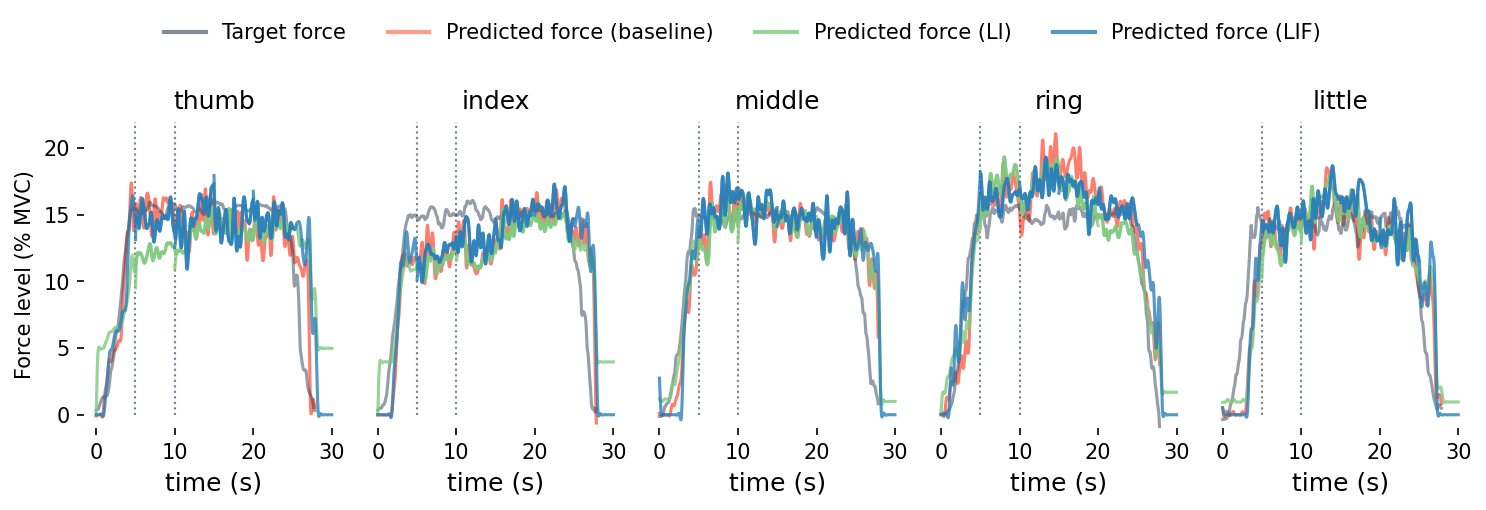

In [95]:
subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-1,22),
                                                        xlim= None, # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                        # source_data_path=os.path.join(project_dir, source_data_main_file),
                                                        # sheet_name="Fig4_snn_lr"
                                                        
                            )

['S1', 'S1'] ['intra', 'intra'] [1, 1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_
Saving figure to S1_ypred_15_leaky_xlim_5_10_testrep_2_testsign_1_intra mu spike count_intra mu spike times.png


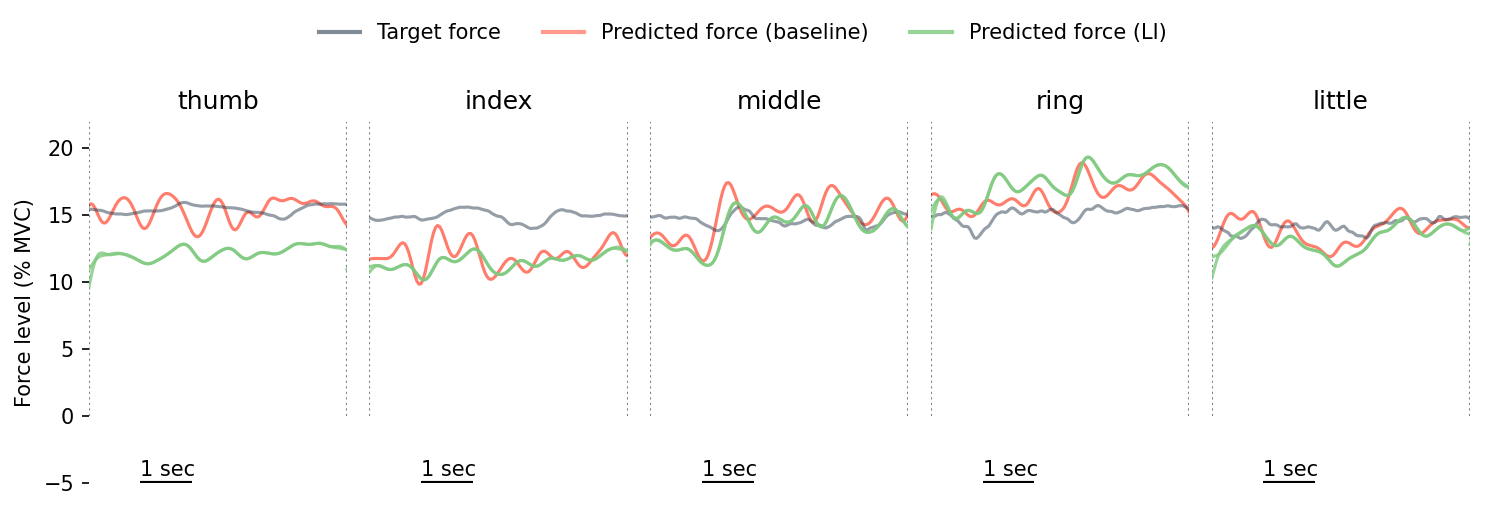

In [97]:
subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                        
                            )

['S1', 'S1'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_spiking_
Saving figure to S1_ypred_15_leaky_spiking_testrep_2_testsign_-1.pdf


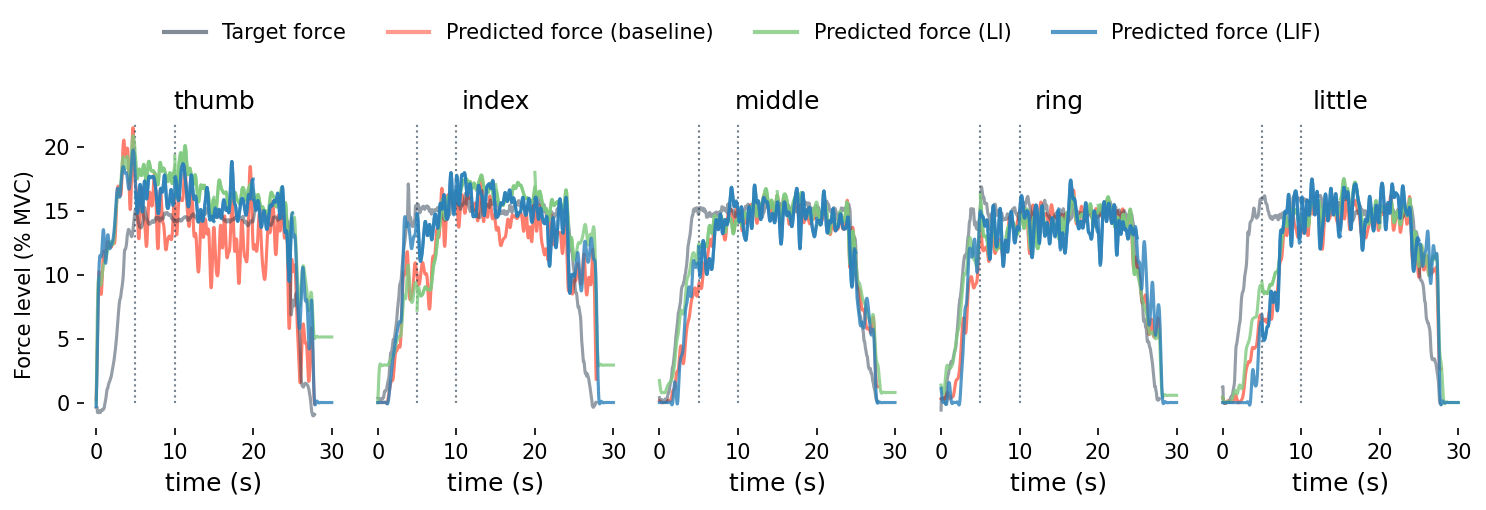

In [99]:
subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-2,22),
                                                        xlim= None, # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                        # source_data_path=os.path.join(project_dir, source_data_si_file),
                                                        # sheet_name="SFig3_snn_lr"
                                                        
                            )

['S1', 'S1'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_
Saving figure to S1_ypred_15_leaky_xlim_5_10_testrep_2_testsign_-1_intra mu spike count_intra mu spike times.png


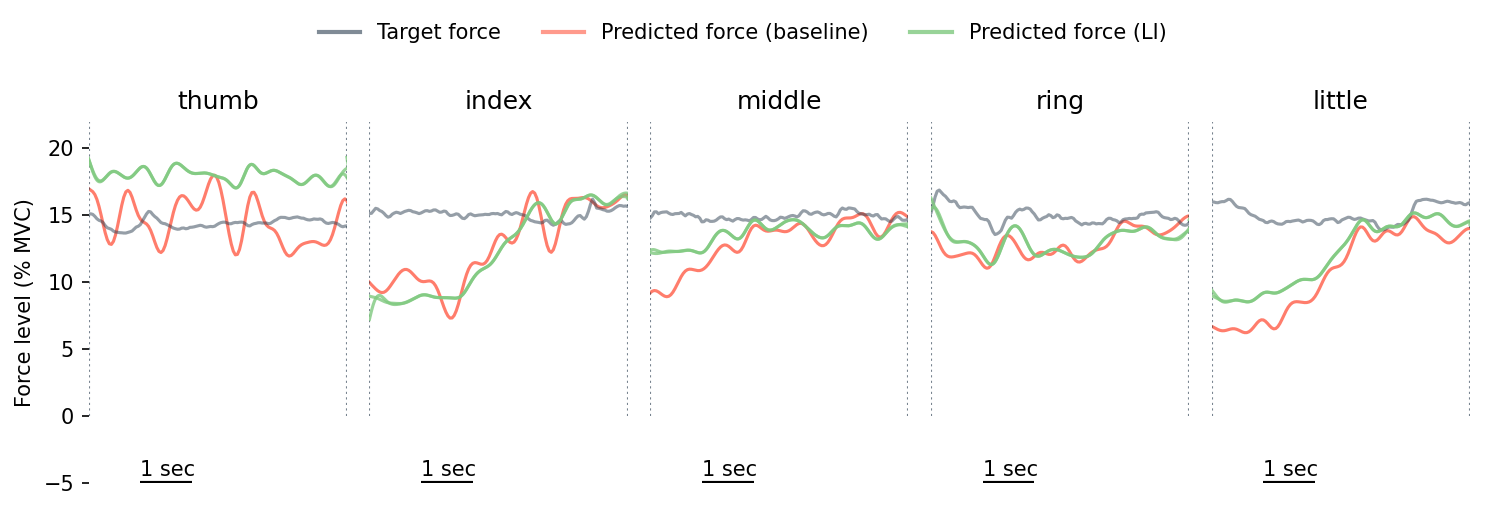

In [104]:
subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                  
                                                        
                            )

['S1', 'S1'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:spiking_
Saving figure to S1_ypred_15_spiking_xlim_5_10_testrep_2_testsign_-1_intra mu spike count_intra mu spike times.png


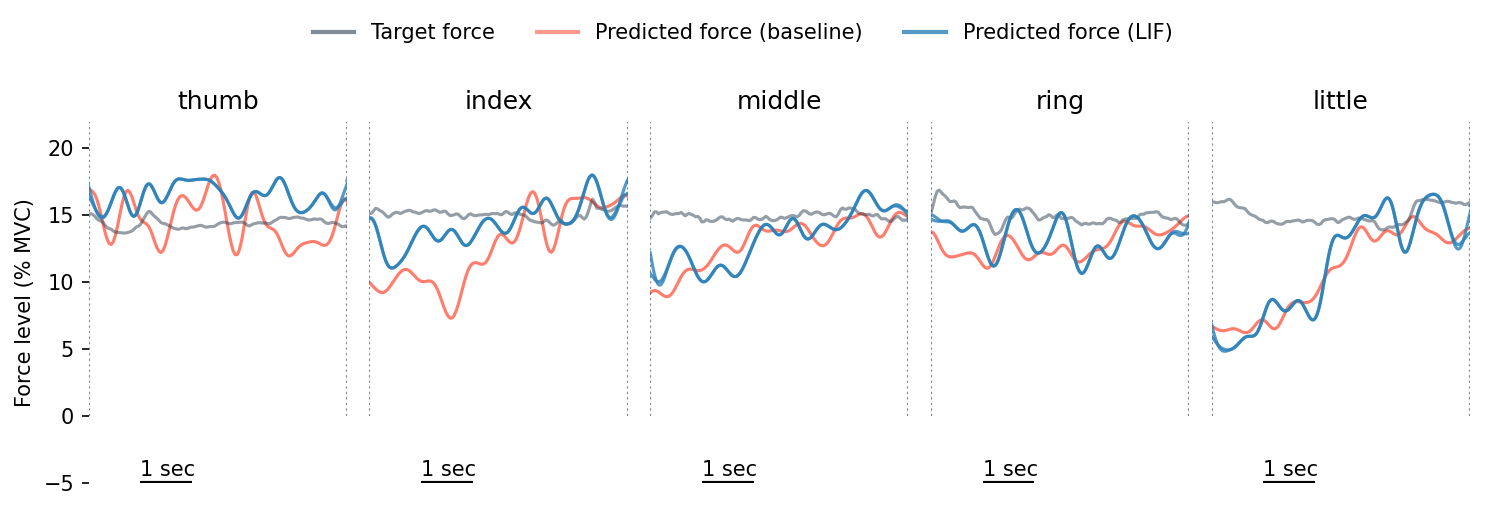

In [105]:
subjects = ["S1", "S1"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                  
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_spiking_
Saving figure to S2_ypred_15_leaky_spiking_testrep_2_testsign_-1.pdf


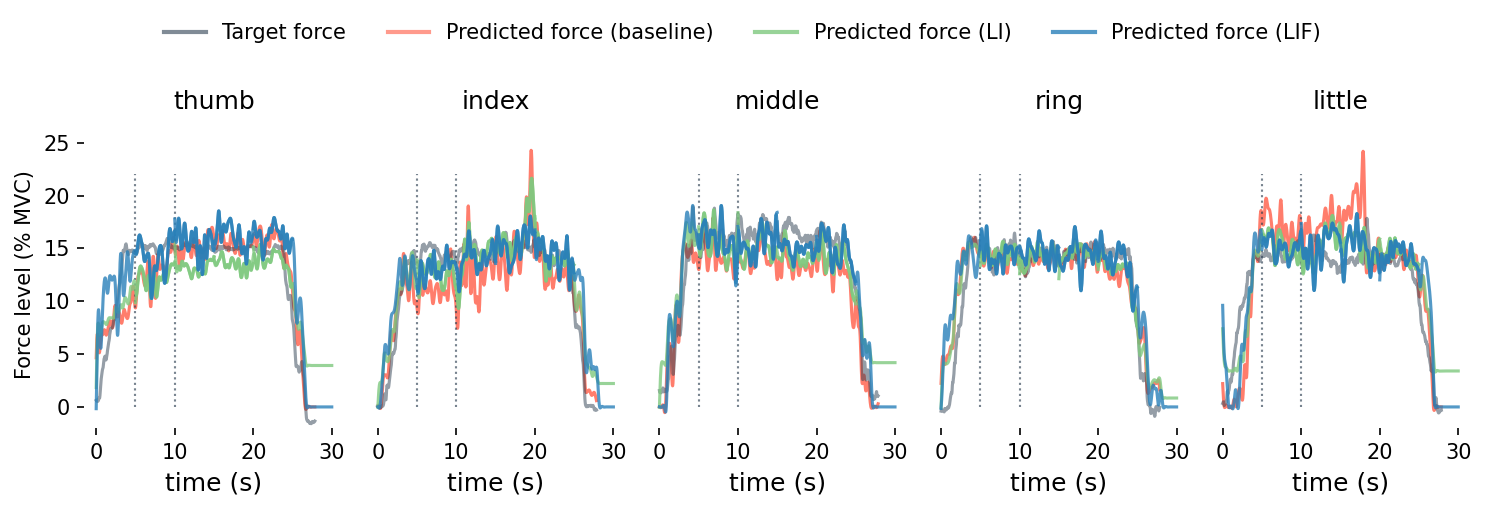

In [108]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-2,27),
                                                        xlim= None, # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                        # source_data_path=os.path.join(project_dir, source_data_si_file),
                                                        # sheet_name="SFig4_snn_lr"
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_
Saving figure to S2_ypred_15_leaky_xlim_5_10_testrep_2_testsign_-1_intra mu spike count_intra mu spike times.png


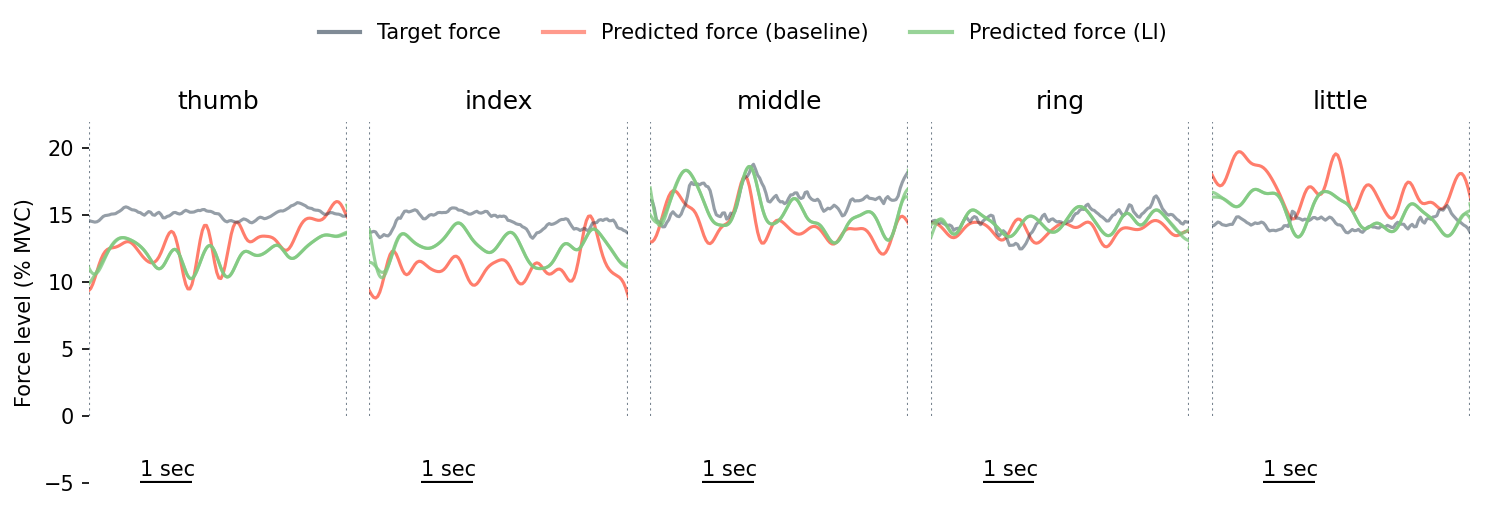

In [106]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                         
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [-1, -1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:spiking_
Saving figure to S2_ypred_15_spiking_xlim_5_10_testrep_2_testsign_-1_intra mu spike count_intra mu spike times.png


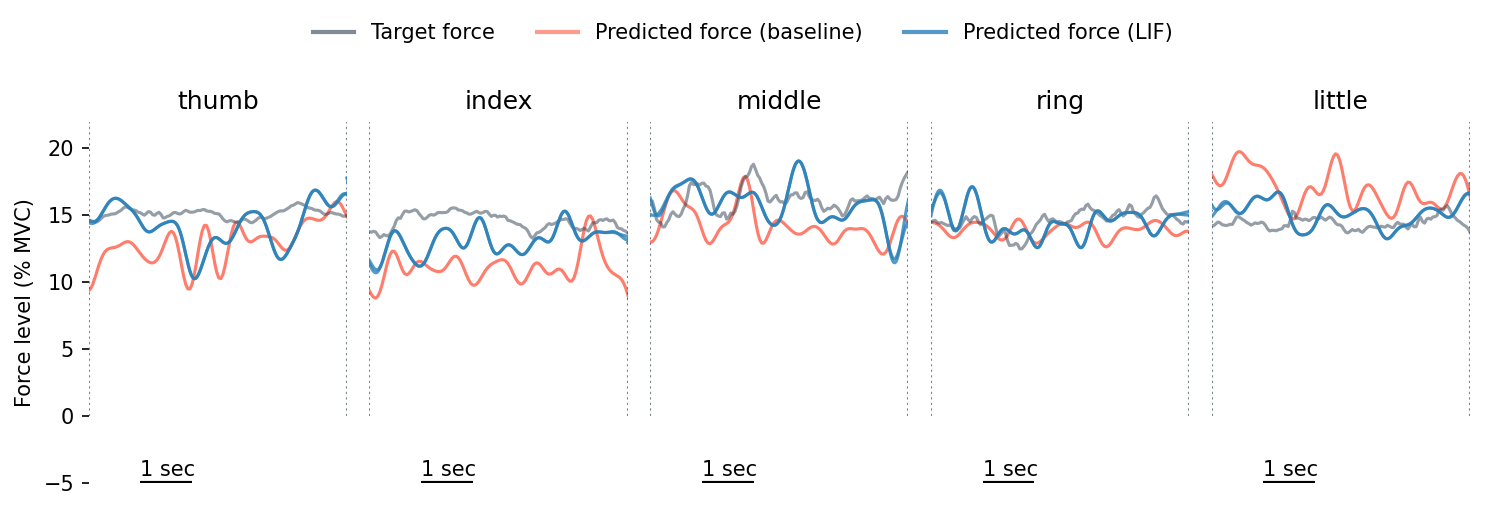

In [107]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [-1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                         
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [1, 1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_spiking_
Saving figure to S2_ypred_15_leaky_spiking_testrep_2_testsign_1.pdf


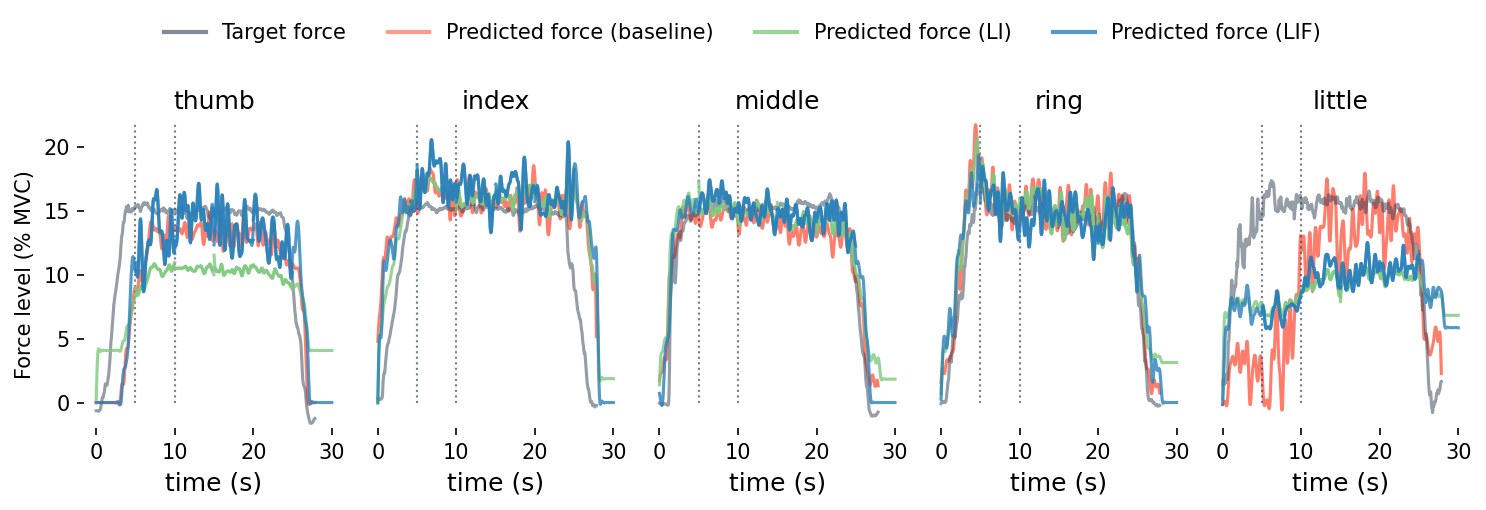

In [103]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-2,22),
                                                        xlim= None, # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY, SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                                        # source_data_path=os.path.join(project_dir, source_data_si_file),
                                                        # sheet_name="SFig5_snn_lr"
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [1, 1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:leaky_
Saving figure to S2_ypred_15_leaky_xlim_5_10_testrep_2_testsign_1_intra mu spike count_intra mu spike times.png


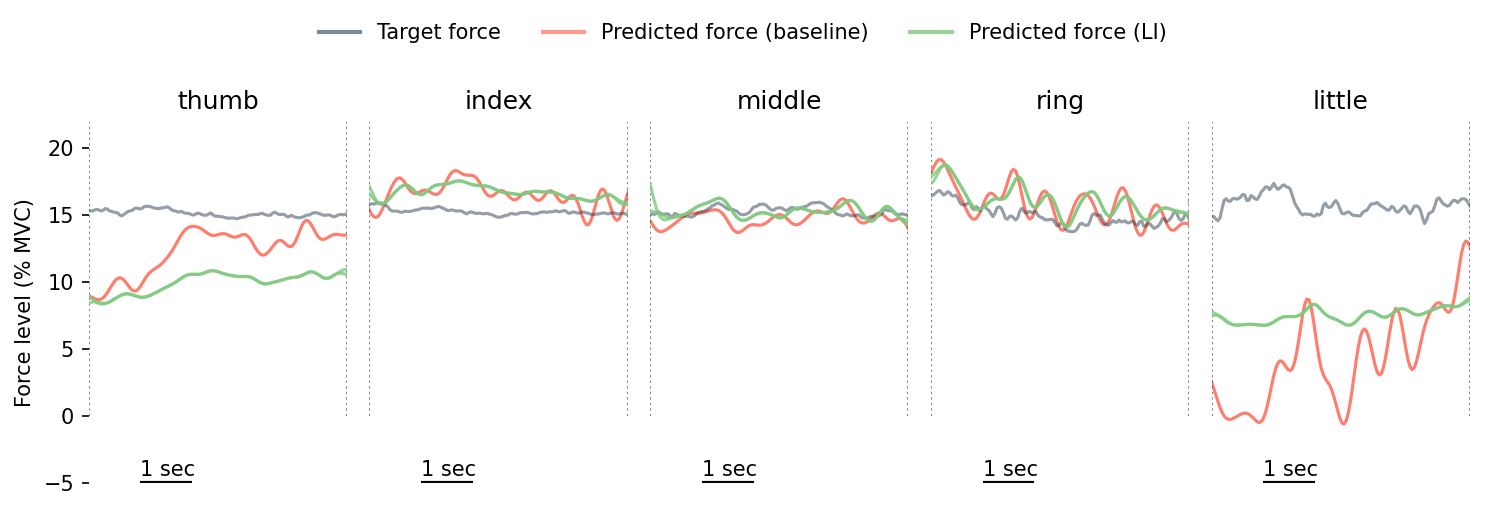

In [110]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_LEAKY],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                       
                                                        
                            )

['S2', 'S2'] ['intra', 'intra'] [1, 1] [15, 15] ['MU spike count', 'MU spike times'] [2, 2]
Comparing models:['intra mu spike count', 'intra mu spike times']
(25000, 5)
(5,) [25.]
stride in steps:500   seg_nsteps:1000
topology string:spiking_
Saving figure to S2_ypred_15_spiking_xlim_5_10_testrep_2_testsign_1_intra mu spike count_intra mu spike times.png


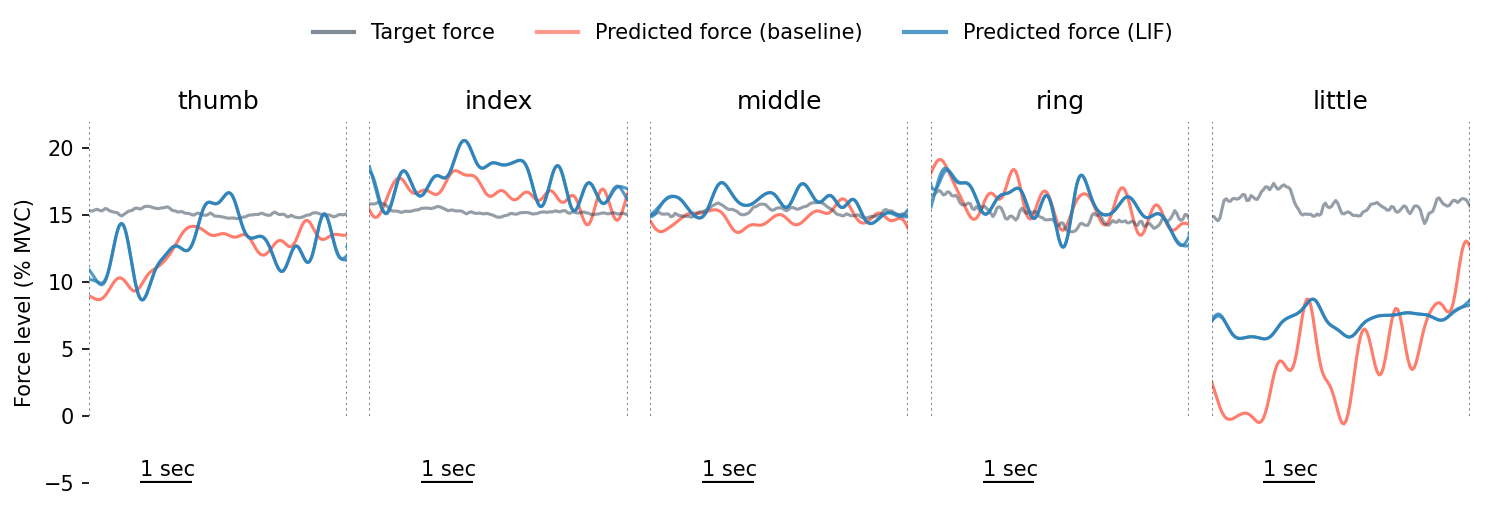

In [111]:
subjects = ["S2", "S2"]
emg_types = ["intra", "intra"]
sign_mvcs = [1]*len(emg_types)
mvcs = [15] * len(emg_types)
input_types = [INPUT_TYPE_SP_COUNT, INPUT_TYPE_SP_TIMES]
reps = [2] * len(emg_types)
snn_params_for_topology = {SHALLOW_LEAKY:flat_leaky_config,
                           SHALLOW_SPIKING_DOUBLE_FILTER:flat_spiking_config}

print(subjects, emg_types, sign_mvcs, mvcs, input_types, reps)
cr.plot_pred_of_models_target_only_different_topologies(data_config, 
                                                        dataset,
                                                        y_compiled_df_snn_conv[y_compiled_df_snn_conv[SEGMENT_HOLD_COL]==False],
                                                        subjects, emg_types,
                                                        sign_mvcs, mvcs, input_types,
                                                        reps, 
                                                        snn_params_for_topology,
                                                        models_palette_dict=models_palette_dict,
                                                        ylim=(-5,22),
                                                        xlim= (5,10), # for entire profile: None | zoomed-in plateau: (5,10)
                                                        save_figure=True,
                                                        pred_force_alpha=0.9,
                                                        pred_linestyle='solid',
                                                         compiled_results_dir=output_figures_dir,
                                                        show_topology=[SHALLOW_SPIKING_DOUBLE_FILTER],
                                                        show_custom_annotation=True, # show annotation in case of zoomed-in: True
                                       
                                                        
                            )